## Segmentación de clientes
### Análisis de cohortes
#### Exploración y limpieza de datos

In [ ]:
# Lectura de archivo
import pandas as pd
df= pd.read_csv('OnlineRetail.csv', encoding= 'latin')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Dimensiones del dataset
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [11]:
# Algunos items sin descripción tampoco contienen id de cliente
no_description= df[df['Description'].isna()]
no_description

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom


In [ ]:
# Búsqueda de precios e id de clientes no nulos en filas sin descripción
print(sum(no_description['UnitPrice'] > 0.0))
print(sum(no_description['CustomerID'].notna()))

0
0


In [15]:
# Eliminamos valores nulos de la columna de descripción
df_clean= df.dropna(subset= 'Description')

In [ ]:
# Búsqueda de duplicados
df_clean.duplicated().sum()

np.int64(5268)

In [22]:
# Se eliminan duplicados
df_clean= df_clean.drop_duplicates(keep= 'first')

In [ ]:
# Copia del dataframe para realizar cambios
df_retail= df_clean.copy()

In [27]:
# Transformación de la variable de fecha de compra a datetime
df_retail['InvoiceDate']= pd.to_datetime(df_retail['InvoiceDate'])

In [28]:
# Formateo a mes
df_retail['InvoiceMonth']= df_retail['InvoiceDate'].dt.to_period('M')

In [29]:
# Creación de columna cohorte que obtiene la primera fecha de compra
df_retail['Cohort']= df_retail.groupby('CustomerID')['InvoiceMonth'].transform('min')
df_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,Cohort
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12,2011-08
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12,2011-08
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12,2011-08
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12,2011-08


In [30]:
# Diferencia en meses entre la primera compra de cada cliente (mes relativo)
df_retail['Cohort_month']= (
    (df_retail['InvoiceMonth'].dt.year - df_retail['Cohort'].dt.year) * 12 +
(df_retail['InvoiceMonth'].dt.month - df_retail['Cohort'].dt.month))
df_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,Cohort,Cohort_month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12,2010-12,0
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011-12,2011-08,4
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011-12,2011-08,4
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12,2011-08,4
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011-12,2011-08,4


### Conteo de clientes por cohorte
Se genera una tabla dinámica con el conteo de clientes por cohorte (filas) y mes relativo (columnas).<br>
Clientes iniciales o que acaban de registrarse pertenecen a la columna 0, clientes que han dejado pasar un mes desde su primera compra, pertenecen a la columna 1 y así sucesivamente.

In [31]:
# Filtro de mes de cohortes por id de cliente
df_retail_cohort= df_retail.groupby(['Cohort', 'Cohort_month'])['CustomerID'].nunique().reset_index()

In [32]:
df_retail_cohort

,Cohort,Cohort_month,CustomerID
0,2010-12,0,948
1,2010-12,1,362
2,2010-12,2,317
3,2010-12,3,367
4,2010-12,4,341
...,...,...,...
86,2011-10,1,93
87,2011-10,2,46
88,2011-11,0,321
89,2011-11,1,43


In [ ]:
# Tabla dinámica del conteo de clientes por cohorte
df_cohort= df_retail_cohort.pivot(index= 'Cohort',
                                  columns= 'Cohort_month',
                                  values= 'CustomerID')
df_cohort

Cohort_month,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


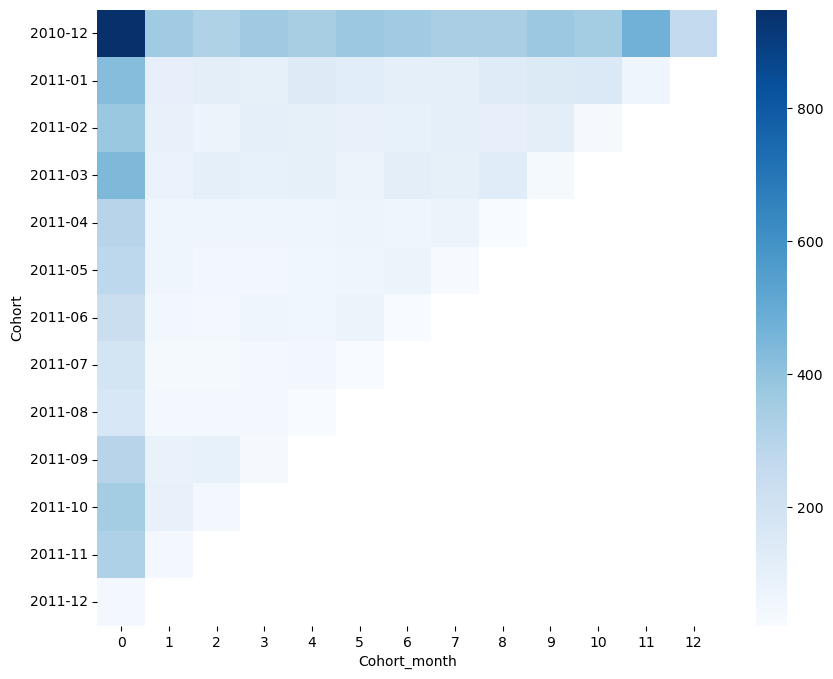

In [ ]:
# Visualización de heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8)) 
sns.heatmap(df_cohort, annot= False, cmap= 'Blues')
plt.show()

### Tasa de Retención
Indica la proporción de clientes que se mantiene usando el producto o servicio durante un periodo determinado:<br>
<center>Cantidad de usuarios mensuales / Total de usuarios registrados o activos


In [ ]:
# Extrae la primera columna de la tabla dinámica (representa el mes de registro)
cohort_size= df_cohort.iloc[:,0]

# Cálculo de la tasa de retención, divide los valores de cada columna entre los clientes iniciales
df_retention= df_cohort.divide(cohort_size, axis=0)

In [35]:
df_retention.round(2)

Cohort_month,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort,,,,,,,,,,,,,
2010-12,1.0,0.38,0.33,0.39,0.36,0.40,0.38,0.35,0.35,0.39,0.37,0.50,0.27
2011-01,1.0,0.24,0.28,0.24,0.33,0.30,0.26,0.26,0.31,0.35,0.37,0.15,NaN
2011-02,1.0,0.25,0.19,0.28,0.27,0.25,0.26,0.28,0.26,0.31,0.09,NaN,NaN
2011-03,1.0,0.19,0.25,0.22,0.23,0.18,0.26,0.24,0.29,0.09,NaN,NaN,NaN
2011-04,1.0,0.23,0.22,0.21,0.21,0.24,0.23,0.26,0.08,NaN,NaN,NaN,NaN
2011-05,1.0,0.24,0.17,0.17,0.22,0.24,0.27,0.10,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.21,0.19,0.27,0.25,0.34,0.10,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.21,0.20,0.23,0.27,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.25,0.25,0.25,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


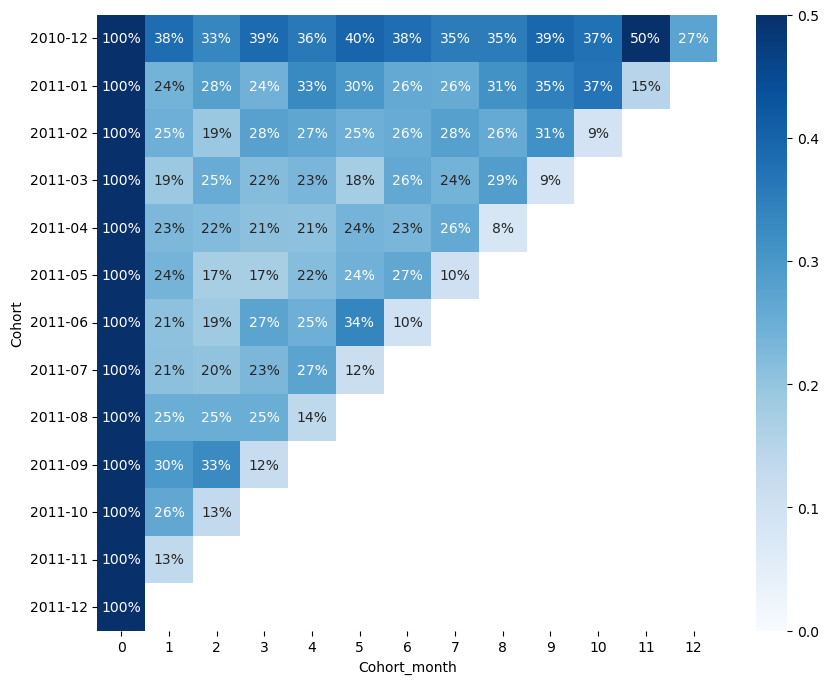

In [ ]:
# Visualización de heatmap
plt.figure(figsize=(10, 8)) 
sns.heatmap(df_retention, annot= True, fmt= '.0%', vmin= 0.0, vmax= 0.5, cmap= 'Blues')
plt.show()

### CLV (Customer Lifetime Value - Valor de vida del cliente)

In [37]:
# Se agrega al dataframe el total de compras para obtener el ingreso mensual
df_retail['Total']= df_retail['Quantity'] * df_retail['UnitPrice']

In [38]:
# Filtro por ingresos
df_retail_revenue_cohort= df_retail.groupby(['Cohort', 'Cohort_month'])['Total'].sum().reset_index()

In [ ]:
# Tabla dinámica del CLV total por cohorte
df_revenue= df_retail_revenue_cohort.pivot(index= 'Cohort',
                                  columns= 'Cohort_month',
                                  values= 'Total')
df_revenue

Cohort_month,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort,,,,,,,,,,,,,
2010-12,552372.860,271081.05,230416.17,301779.44,200555.55,321097.90,312399.91,303427.42,310117.670,465596.61,440585.73,509481.22,182372.79
2011-01,202650.850,56012.50,62153.72,41454.86,82188.99,83890.33,70184.45,72719.78,74270.661,103747.96,121445.26,27773.72,NaN
2011-02,149105.400,25154.66,37286.34,45768.87,35607.95,31016.13,47632.40,55682.10,51735.580,60424.27,9402.07,NaN,NaN
2011-03,189488.390,26364.11,53594.85,40246.52,46495.08,38301.88,60526.94,61205.20,64885.660,11145.36,NaN,NaN,NaN
2011-04,119561.811,28866.80,24896.56,23863.40,25945.51,29550.23,28060.75,33670.78,6273.900,NaN,NaN,NaN,NaN
2011-05,115494.260,17622.89,18838.63,17888.89,26482.28,32850.26,31260.28,10561.72,NaN,NaN,NaN,NaN,NaN
2011-06,92198.360,13552.69,13842.42,29868.80,25751.10,39494.48,7841.48,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,65734.521,11126.27,15349.90,17062.97,18973.77,6024.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,77503.270,19093.33,33016.14,39870.90,14143.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Máximo y mínimo de CLV
print(df_revenue.min().min())
print(df_revenue.max().max())

6024.7
552372.86


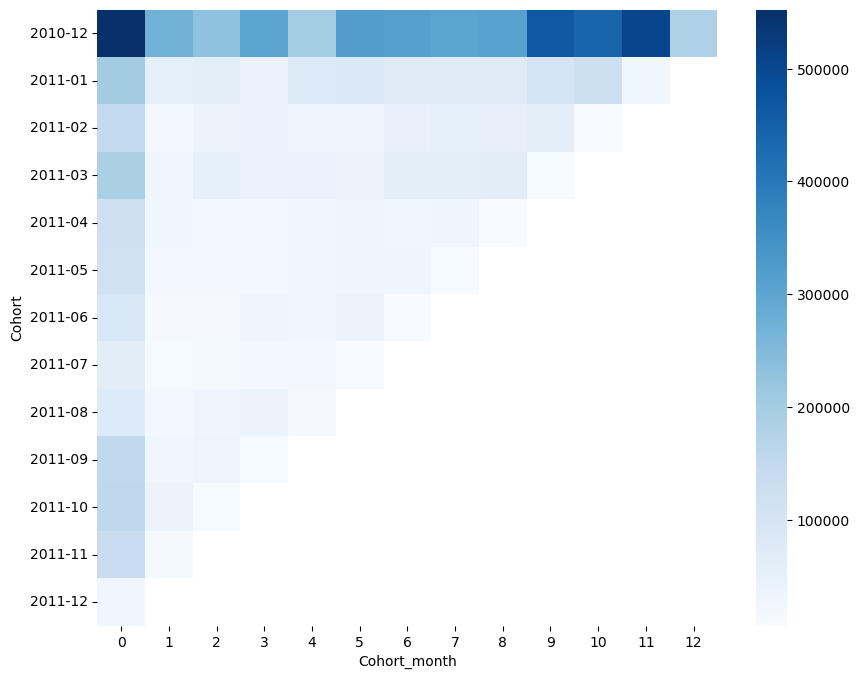

In [41]:
# Heatmap de CLV
plt.figure(figsize=(10, 8)) 
sns.heatmap(df_revenue, annot= False, cmap= 'Blues')
plt.show()

### Tasa de abandono

In [42]:
# La tasa de retención y la tasa de abandono(churn) son métricas complementarias
churn= 1 - df_retention

In [43]:
# Cálculo de tasas de retención y abandono
retention_rate= df_retention.iloc[:,1:].mean().mean().round(2)* 100
churn_rate= churn.iloc[:,1:].mean().mean().round(2)*100

In [44]:
print('Retención: ', retention_rate, '\n', 'Abandono: ', churn_rate)

Retención:  26.0 
 Abandono:  74.0


### Cálculo de CLV (Customer Lifetime Value - Valor de vida del cliente)
Estima el valor monetario que genera un cliente a lo largo del tiempo durante su relación comercial. Fórmula tradicional:<br> 
<center>ingreso promedio * Tasa de retención / Tasa de abandono

In [ ]:
# Cálculo del ingreso mensual en el dataframe
monthly_revenue= df_retail.groupby(['CustomerID', 'InvoiceMonth'])['Total'].sum().mean()
print(monthly_revenue.round(2))

605.38


In [ ]:
# En este ejercicio se definirán tres años como promedio del tiempo que toma al cliente a abandonar el producto
basic_clv= monthly_revenue * 36
print('CLV básico promedio: ', basic_clv.round(2))

CLV básico promedio:  21793.54


##### CLV granular

In [ ]:
# Cálculo de ingreso por factura
per_purchase_revenue= df_retail.groupby('InvoiceNo')['Total'].mean().mean()
print(per_purchase_revenue.round(2))

21.48


In [50]:
# Promedio de facturas por cliente cada mes
customer_frequency= df_retail.groupby(['CustomerID', 'InvoiceMonth'])['InvoiceNo'].nunique().mean()
print(customer_frequency.round(2))

1.62


In [52]:
granular_clv= per_purchase_revenue * customer_frequency * 36
print('CLV granular: ', granular_clv.round(2))

CLV granular:  1255.07


##### CLV tradicional

In [ ]:
# Cálculo de CLV tradicional (se omite el tiempo de vida estimado de tres meses de los dos ejemplos anteriores)
clv= monthly_revenue * (retention_rate/ churn_rate)
print('CLV tradicional:', clv.round(2), 'al', retention_rate,  '% de retención')

CLV tradicional: 212.7 al 26.0 % de retención


<b>Observaciones:</b>
- Las métricas son descendentes, <b>los clientes tienen a hacer menos compras con el paso del tiempo</b>, por lo tanto, su CLV disminuye.
- De igual manera, las mayores tasas de retención ocurren durante el primer cohorte (diciembre de 2010).
- El CLV promedio es de <b>212 unidades monetarias</b>.
- La tasa de retención general es del <b>26%</b>
- La tasa de abandono es del <b>74%</b>

### Segmentación RFM (Recency, Frequency, Monetary)
Herramienta o metodología en marketing que se utiliza para la comprensión y segmentación de clientes.<br>
- <b>Recencia</b>: Cuán reciente ha sido una compra en un determinado tiempo.
- <b>Frecuencia</b>: Mide la lealtad del cliente, cada cuánto tiempo se ha realizado una compra durante un periodo específico.
- <b>Valor monetario</b>: Cuál es el valor monetario que un cliente aporta durante determinado tiempo.

In [54]:
from datetime import timedelta

In [55]:
# Se creará una fecha hipotética para obtener la recencia, un día más del dataset
max_date= max(df_retail['InvoiceDate']) + timedelta(days= 1)
print(max_date)

2011-12-10 12:50:00


In [56]:
# Dataframe del cálculo de las métricas RFM
rfm_df= df_retail.groupby('CustomerID').agg({'InvoiceDate': lambda x: (max_date - x.max()).days,
                                     'InvoiceNo': 'count',
                                     'Total': 'sum'})

In [57]:
# Se renombran las columnas con los nombres de las métricas
rfm_df.rename(columns= {'InvoiceDate': 'Recency',
                        'InvoiceNo': 'Frequency',
                        'Total': 'Monetary_value'}, inplace= True)

In [ ]:
# La primera fila indica una posible devolución de producto
rfm_df.head()

,Recency,Frequency,Monetary_value
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [59]:
# Asigación de cuartiles a los clientes
# Sólo en el cálculo de recencia se definen labels (etiquetas) con valores descendentes, ya que la mejor clasificación es para valores menores.
r_quartiles= pd.qcut(rfm_df['Recency'], q= 4, labels= range(4, 0, -1))
r_quartiles

CustomerID
12346.0    1
12347.0    4
12348.0    2
12349.0    3
12350.0    1
          ..
18280.0    1
18281.0    1
18282.0    4
18283.0    4
18287.0    3
Name: Recency, Length: 4372, dtype: category
Categories (4, int64): [4 < 3 < 2 < 1]

In [60]:
# Asignación de cuartiles al dataframe
rfm_df= rfm_df.assign(R= r_quartiles.values)

In [61]:
rfm_df.head()

,Recency,Frequency,Monetary_value,R
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,182,4310.00,4
12348.0,75,31,1797.24,2
12349.0,19,73,1757.55,3
12350.0,310,17,334.40,1


In [62]:
# Cálculo de Frequency y Monetary value
f_quartiles= pd.qcut(rfm_df['Frequency'], q= 4, labels= range(1, 5))
m_quartiles= pd.qcut(rfm_df['Monetary_value'], q= 4, labels= range(1, 5))

In [63]:
# Asignación a dataframe
rfm_df= rfm_df.assign(F= f_quartiles.values)
rfm_df= rfm_df.assign(M= m_quartiles.values)
rfm_df.head()

,Recency,Frequency,Monetary_value,R,F,M
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,182,4310.00,4,4,4
12348.0,75,31,1797.24,2,2,4
12349.0,19,73,1757.55,3,3,4
12350.0,310,17,334.40,1,1,2


In [64]:
# Creación de puntuación RFM, suma de cada métrica
rfm_df['RFM_score']= rfm_df[['R', 'F', 'M']].sum(axis= 1)
rfm_df.head()

,Recency,Frequency,Monetary_value,R,F,M,RFM_score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,3
12347.0,2,182,4310.00,4,4,4,12
12348.0,75,31,1797.24,2,2,4,8
12349.0,19,73,1757.55,3,3,4,10
12350.0,310,17,334.40,1,1,2,4


In [65]:
# Segmento RFM, concatenación de las métricas
def rfm_segment(x): return str(x['R']) + str(x['F']) + str(x['M'])

In [67]:
rfm_df['RFM_segment']= rfm_df.apply(rfm_segment, axis= 1)
rfm_df.head()

,Recency,Frequency,Monetary_value,R,F,M,RFM_score,RFM_segment
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,1,1,3,111
12347.0,2,182,4310.00,4,4,4,12,444
12348.0,75,31,1797.24,2,2,4,8,224
12349.0,19,73,1757.55,3,3,4,10,334
12350.0,310,17,334.40,1,1,2,4,112


In [68]:
# Selección de clientes en función de su segmento RFM
rfm_df.groupby('RFM_segment').size().sort_values()

RFM_segment
241      1
441      1
414      3
142      3
124      6
      ... 
211    181
122    204
344    210
111    393
444    470
Length: 62, dtype: int64

In [69]:
# Agrupación en segmentos de clientes con denominación Bronze, Silver, Gold en función a su puntuación
def segment_name(df):
    if df['RFM_score'] >= 9:
        return 'Gold'
    elif (df['RFM_score'] >= 5) and  (df['RFM_score'] < 9):
        return 'Silver'
    else:
        return 'Bronze' 

In [70]:
# Promedio de cada categoría o segmento general de clientes
rfm_df['General_segment']= rfm_df.apply(segment_name, axis= 1)
rfm_df.groupby('General_segment').agg({'Recency': 'mean',
                                       'Frequency': 'mean',
                                       'Monetary_value': ['mean', 'count']}).round(1)

Recency Frequency Monetary_value      
                   mean      mean           mean count
General_segment                                       
Bronze            220.0      10.8          167.7   783
Gold               25.3     191.7         4103.8  1699
Silver             99.0      35.6          621.6  1890

<b>Conclusión general:</b>
- En la segmentación RFM, el orden es el siguiente:
    1. <b>Plata</b>: Clientes potenciales.
    2. <b>Oro</b>: Clientes de alto valor (gastos altos, alta frecuencia de compra y baja tasa de abandono).
    3. <b>Bronce</b>: Clientes nuevos o clientes de bajo valor (alta tasa de abandono).
- Existe poca fidelización por parte de los clientes, <b>la mayoría no permanecen más de un año</b>.
- Se debería dar prioridad a <b>estrategias de retención</b> (programas de lealtad, descuentos exclusivos, comunicación constante). 
- Mantener fidelidad de Oro, incentivar a Plata y Bronce.